In [1]:
%matplotlib inline
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#help(cv.imread)

In [3]:
folder = Path('./white_patch')

images = []
for file_path in folder.iterdir():
    if file_path.is_file():
        images.append(cv.imread(str(file_path)))

#for image in images:
#    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
#    plt.show()


In [4]:
def white_patch(input_image:np.ndarray) -> np.ndarray:
    blue, green, red = cv.split(input_image)
    max_red = np.max(red)
    max_green = np.max(green)
    max_blue = np.max(blue)

    red = (red / max_red * 255).astype(np.uint8) if max_red != 0 else np.zeros_like(red)
    green = (green / max_green * 255).astype(np.uint8) if max_green != 0 else np.zeros_like(green)
    blue = (blue / max_blue * 255).astype(np.uint8) if max_blue != 0 else np.zeros_like(blue)

    return cv.merge([blue, green, red])

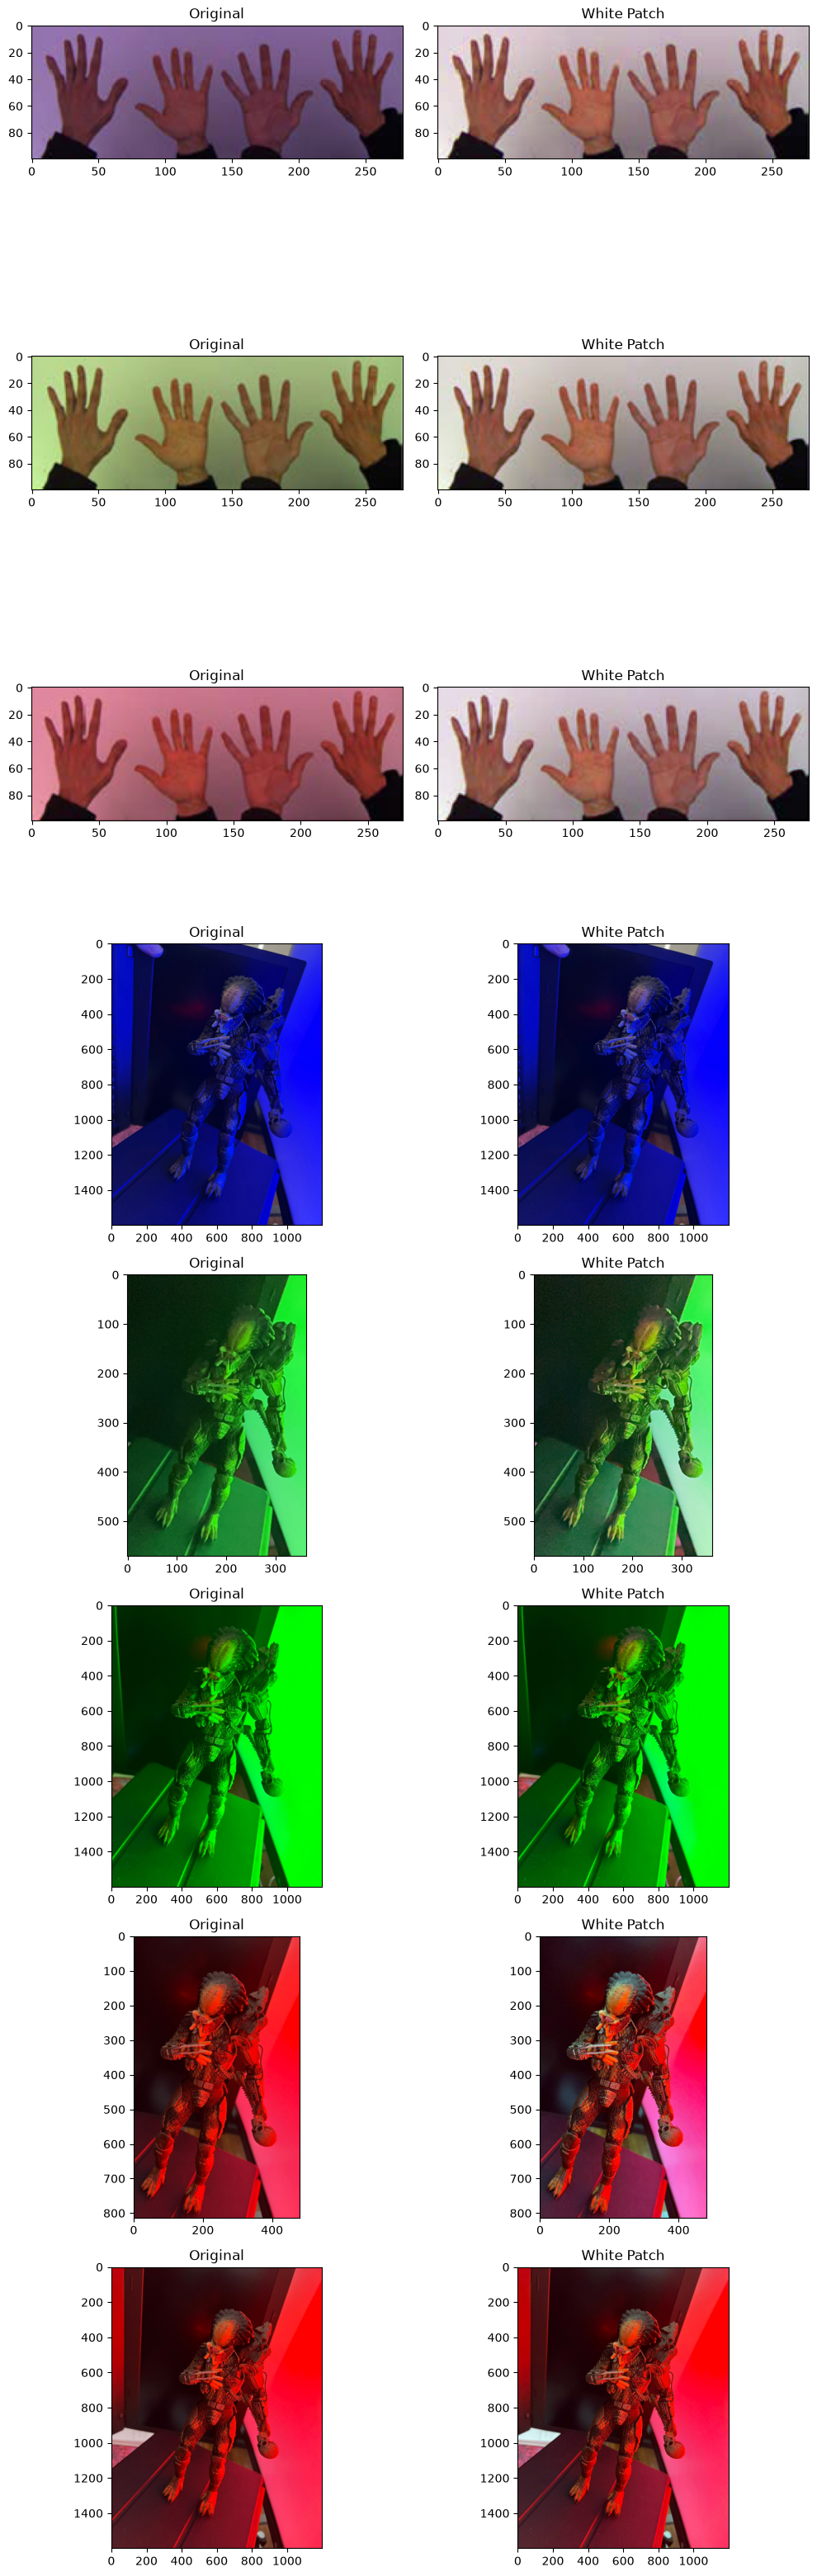

In [5]:
fig, axes = plt.subplots(nrows=len(images), ncols=2, figsize=(10, 4 * len(images)))

for i, image in enumerate(images):
    patched_image = white_patch(image)

    ax0 = axes[i, 0]
    ax1 = axes[i, 1]

    ax0.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB), vmin=0, vmax=255)
    ax0.set_title('Original')

    ax1.imshow(cv.cvtColor(patched_image, cv.COLOR_BGR2RGB), vmin=0, vmax=255)
    ax1.set_title('White Patch')

plt.tight_layout()
plt.show()


El algoritmo es bueno en casos donde se necesita resaltar los blancos. Esto se puede observar, particularmente, en las imágenes de las manos. En casos como las imágenes de los aliens, pareciera que la falta de blancos hace que el output no tenga mucha variación con respecto a la imagen de entrada.
Por otro lado, haciendo pruebas, si la imagen tuviese algún pixel con ruido, podría perturbar el parcheo, es decir, es muy sensible a los píxeles, dejo un ejemplo a continuación.

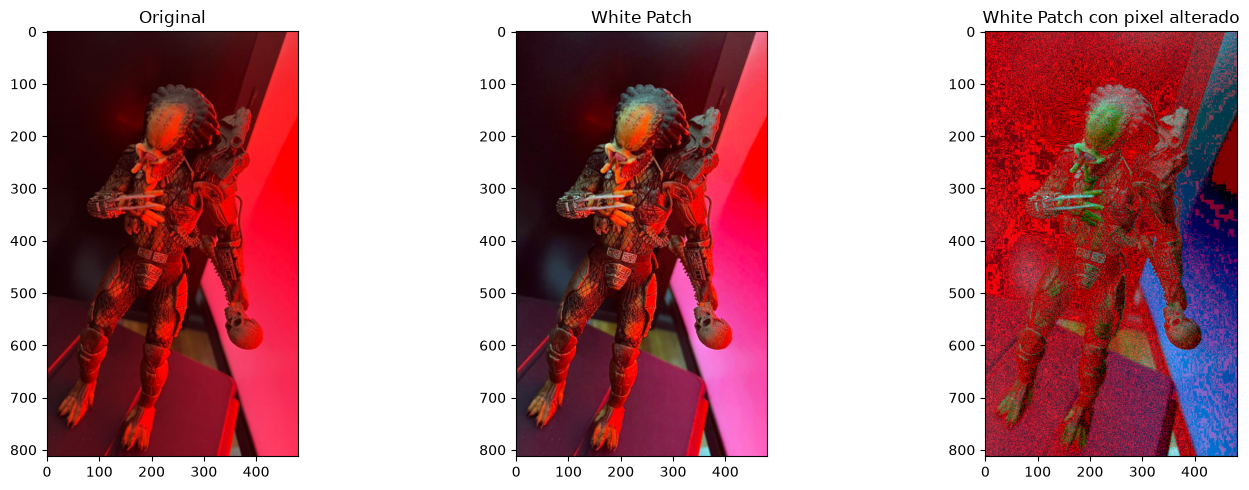

In [6]:
def white_patch_with_noise(input_image:np.ndarray) -> np.ndarray:
    blue, green, red = cv.split(input_image)
    max_red = 2
    max_green = np.max(green)
    max_blue = np.max(blue)

    # Altero el pixel máx. del rojo para interpretar que hay alguno con ruido
    red = (red / max_red * 255).astype(np.uint8) if max_red != 0 else np.zeros_like(red)
    green = (green / max_green * 255).astype(np.uint8) if max_green != 0 else np.zeros_like(green)
    blue = (blue / max_blue * 255).astype(np.uint8) if max_blue != 0 else np.zeros_like(blue)

    return cv.merge([blue, green, red])

test = cv.imread('white_patch/wp_red.png')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

axes[0].imshow(cv.cvtColor(test, cv.COLOR_BGR2RGB), vmin=0, vmax=255)
axes[0].set_title('Original')

axes[1].imshow(cv.cvtColor(white_patch(test), cv.COLOR_BGR2RGB), vmin=0, vmax=255)
axes[1].set_title('White Patch')

axes[2].imshow(cv.cvtColor(white_patch_with_noise(test), cv.COLOR_BGR2RGB), vmin=0, vmax=255)
axes[2].set_title('White Patch con pixel alterado')


plt.tight_layout()
plt.show()



----------------------------------------------------------

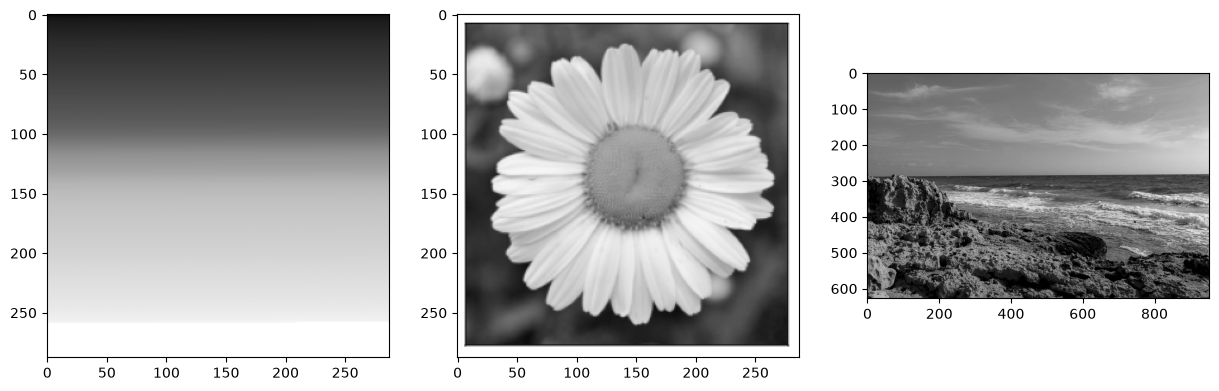

In [7]:
images = [cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE),cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE), cv.imread('segmentacion.png', cv.IMREAD_GRAYSCALE) ]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes[0].imshow(images[0], cmap='gray', vmin=0, vmax=255)
axes[1].imshow(images[1], cmap='gray', vmin=0, vmax=255)
axes[2].imshow(images[2], cmap='gray', vmin=0, vmax=255)
plt.show()


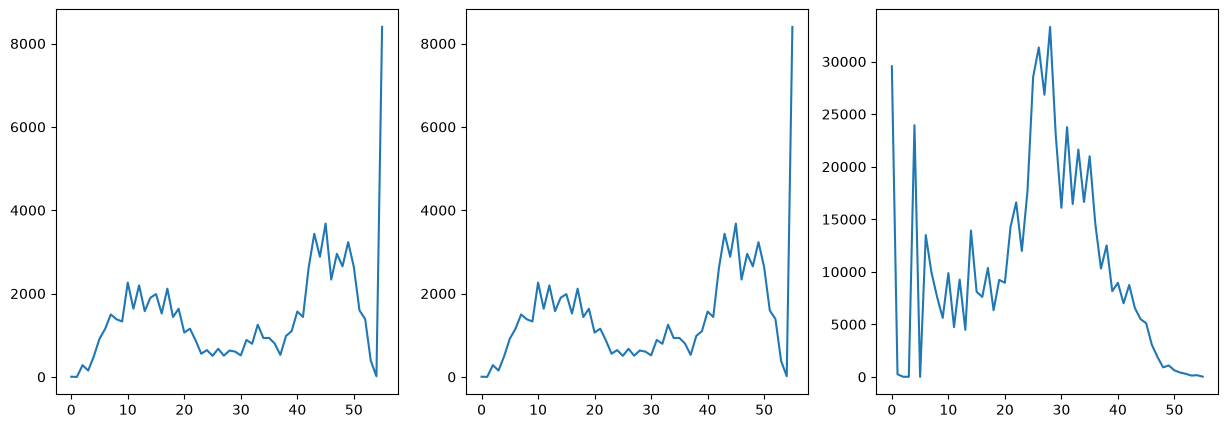

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

hist1,bins1 = np.histogram(images[0].ravel(), 56, [0, 256])
hist2,bins2 = np.histogram(images[1].ravel(),56,[0,256])
hist3,bins3 = np.histogram(images[2].ravel(),56,[0,256])

axes[0].plot(hist1)
axes[1].plot(hist2)
axes[2].plot(hist3)
plt.show()


Para este análisis, tomé 56 bins para graficar los histogramas. Si tuviese que basasrme en esto para hacer la clasificación de un objeto, diría que no es útil. La imagen 1 y 2 son completamente distinas, de hecho, la imagen 1 no tiene ningún objeto, sin embargo, la distribución de bines es visualmente idéntica. Un algoritmo basándose en eso podría intentar clasificar ambas imágenes como lo mismo cuando no tienen nada que ver.
Los histogramas nos permiten visualizar la distribución de intensidad píxeles en una imagen, pero no nos dicen nada de la imagen en si.